<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 159.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 172.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 155.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 155.6 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [8]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head(10)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
9,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


<h4>Bar Chart:</h4>

In [15]:
##Identify the industry column:
df_industry = df.columns[df.columns.str.contains("industry", case=False, na=False)]

print(df_industry)

Index(['Industry'], dtype='str')


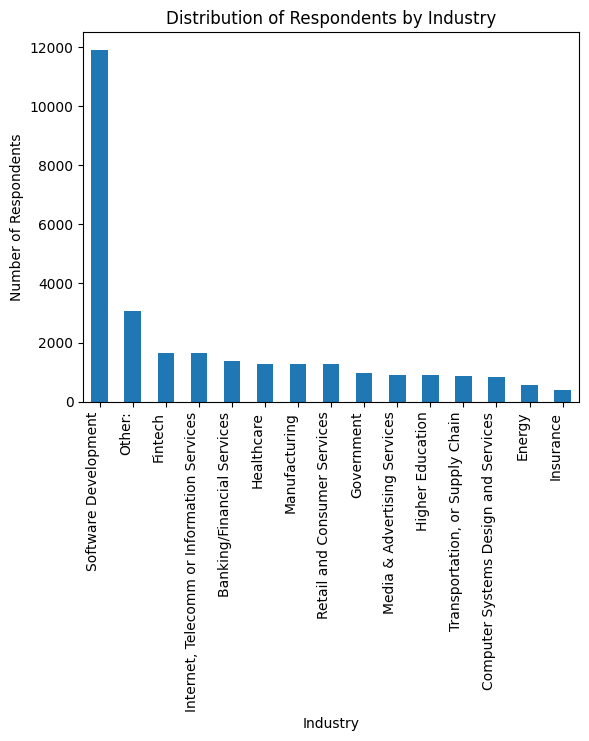

In [16]:
##Plot bar graph
industry_counts = df["Industry"].value_counts()

industry_counts.plot(kind="bar")

plt.title("Distribution of Respondents by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=90, ha="right")
plt.show()


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


<b>Summary statistics for ConvertedCompYearly</b>

In [27]:
CCY_mean = df["ConvertedCompYearly"].mean()
print(f"Mean for ConvertedCompyYearly: {CCY_mean}")
CCY_median = df["ConvertedCompYearly"].median()
print(f"Median for ConvertedCompyYearly: {CCY_median}")
CCY_std = df["ConvertedCompYearly"].std()
print(f"Standard Deviation for ConvertedCompyYearly: {CCY_std}")

Mean for ConvertedCompyYearly: 86155.28726264134
Median for ConvertedCompyYearly: 65000.0
Standard Deviation for ConvertedCompyYearly: 186756.97308629757


<b>Values exceeding 3 standard deviations above the mean</b>

In [30]:
outlier_threshold = CCY_mean + (3 * CCY_std)
print(f"Outlier threshold: {outlier_threshold}")

# Filter rows where ConvertedCompYearly is above the threshold
high_comp_outliers = df[df["ConvertedCompYearly"] > outlier_threshold]
print(f"Number of high compensation outliers: {len(high_comp_outliers)}")

# Display the outliers
high_comp_outliers[["ConvertedCompYearly"]].sort_values(by="ConvertedCompYearly", ascending=False)

Outlier threshold: 646426.2065215341
Number of high compensation outliers: 89


,ConvertedCompYearly
15837,16256603.0
12723,13818022.0
28379,9000000.0
17593,6340564.0
17672,4936778.0
...,...
13336,660660.0
6735,650000.0
529,650000.0
28381,650000.0


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


<b>Interquartile Range and upper and lower bounds</b>

In [32]:
# Calculate Q1 and Q3
Q1 = df["ConvertedCompYearly"].quantile(0.25)
Q3 = df["ConvertedCompYearly"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

comp_outliers = df[
    (df["ConvertedCompYearly"] < lower_bound) |
    (df["ConvertedCompYearly"] > upper_bound)
]

print(f"Number of compensation outliers: {len(comp_outliers)}")

comp_outliers[["ConvertedCompYearly"]].sort_values(
    by="ConvertedCompYearly",
    ascending=False
)

Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower bound: -80177.25
Upper bound: 220860.75
Number of compensation outliers: 978


,ConvertedCompYearly
15837,16256603.0
12723,13818022.0
28379,9000000.0
17593,6340564.0
17672,4936778.0
...,...
25958,222000.0
36158,222000.0
39168,221746.0
8418,221713.0


<b>Box Plot</b>

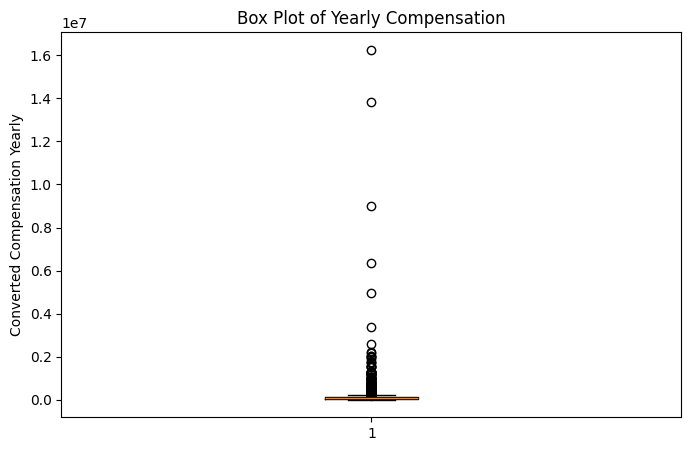

In [33]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["ConvertedCompYearly"].dropna())

plt.title("Box Plot of Yearly Compensation")
plt.ylabel("Converted Compensation Yearly")

plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [34]:
df_no_outliers = df[
    (df["ConvertedCompYearly"] >= lower_bound) &
    (df["ConvertedCompYearly"] <= upper_bound)
]

# Validate the size of the original and new DataFrame
print(f"Original DataFrame shape: {df.shape}")
print(f"New DataFrame shape without outliers: {df_no_outliers.shape}")
print(f"Number of rows removed: {df.shape[0] - df_no_outliers.shape[0]}")

Original DataFrame shape: (65437, 114)
New DataFrame shape without outliers: (22457, 114)
Number of rows removed: 42980


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


<b>Mapping the Age column to approximate numeric values</b>


In [37]:
df["Age"].value_counts()

age_mapping = {
    "Under 18 years old": 16,
    "18-24 years old": 21,
    "25-34 years old": 30,
    "35-44 years old": 40,
    "45-54 years old": 50,
    "55-64 years old": 60,
    "65 years or older": 70,
    "Prefer not to say": None
}

df["Age_Numeric"] = df["Age"].map(age_mapping)

df[["Age", "Age_Numeric"]].head()

,Age,Age_Numeric
0,Under 18 years old,16.0
1,35-44 years old,40.0
2,45-54 years old,50.0
3,18-24 years old,21.0
4,18-24 years old,21.0


In [38]:
# Select numeric columns only
numeric_df = df.select_dtypes(include="number")

# Compute correlations
correlation_matrix = numeric_df.corr()

# Show correlations with Age_Numeric
age_correlations = correlation_matrix["Age_Numeric"].sort_values(ascending=False)

print(age_correlations)

Age_Numeric            1.000000
WorkExp                0.848803
ConvertedCompYearly    0.122133
JobSat                 0.069818
CompTotal             -0.002698
JobSatPoints_1        -0.027675
ResponseId            -0.038245
JobSatPoints_8        -0.046204
JobSatPoints_6        -0.050017
JobSatPoints_4        -0.076150
JobSatPoints_9        -0.081759
JobSatPoints_7        -0.083232
JobSatPoints_5        -0.101560
JobSatPoints_11       -0.107170
JobSatPoints_10       -0.114571
Name: Age_Numeric, dtype: float64


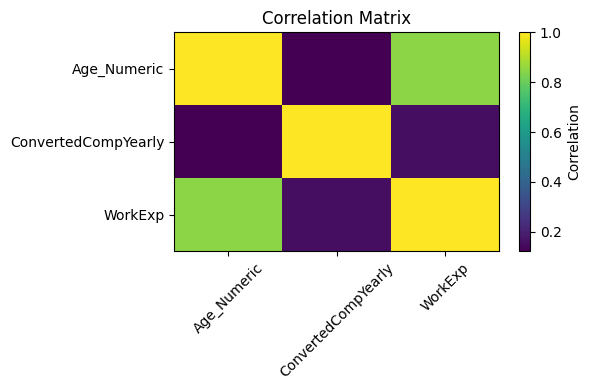

In [40]:
selected_columns = [
    "Age_Numeric",
    "ConvertedCompYearly",
    "WorkExp"
]

selected_columns = [col for col in selected_columns if col in df.columns]

small_corr = df[selected_columns].corr()

plt.figure(figsize=(6, 4))
plt.imshow(small_corr, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(small_corr.columns)), small_corr.columns, rotation=45)
plt.yticks(range(len(small_corr.columns)), small_corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
